In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir) 

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [2]:
# Toy example: why gradient=ones_like is needed for vector outputs
import torch

# Scalar output: gradient=None and gradient=ones are equivalent
x_scalar = torch.tensor(2.0, requires_grad=True)
y_scalar = x_scalar ** 3  # scalar
y_scalar.backward()
grad_none = x_scalar.grad.item()
x_scalar.grad.zero_()
y_scalar = x_scalar ** 3  # recompute graph
y_scalar.backward(gradient=torch.ones_like(y_scalar))
grad_ones = x_scalar.grad.item()
print("Scalar output:")
print("  grad with None:", grad_none)
print("  grad with ones:", grad_ones)

# Vector output: gradient=None raises error; ones_like gives sum of grads
x_vec = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y_vec = x_vec ** 2  # vector
print("\nVector output:")
try:
    y_vec.backward()
except RuntimeError as exc:
    print("  backward(None) error:", exc)
x_vec.grad = None
y_vec = x_vec ** 2  # recompute graph
y_vec.backward(gradient=torch.ones_like(y_vec))
print("  grad with ones:", x_vec.grad.tolist())
print("  expected (2*x):", (2 * x_vec).tolist())

Scalar output:
  grad with None: 12.0
  grad with ones: 12.0

Vector output:
  backward(None) error: grad can be implicitly created only for scalar outputs
  grad with ones: [2.0, 4.0, 6.0]
  expected (2*x): [2.0, 4.0, 6.0]


In [3]:
import bcosgnn
import torch
import torch_geometric
import functools
import itertools
import operator
from pathlib import Path
from typing import Any
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import torch.nn.functional as F
from bcosgnn.explain import explain
import torch.nn as nn
from torch_geometric.nn import GINConv, global_mean_pool
from sklearn.metrics import f1_score, accuracy_score

/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def _augment_with_normalized_pos(dataset):
    augmented = []
    for data in dataset:
        d = data.clone()
        pos = d.pos.float()
        pos_min = pos.min(dim=0).values
        pos_max = pos.max(dim=0).values
        denom = (pos_max - pos_min).clamp(min=1e-8)
        pos_norm = (pos - pos_min) / denom

        intensity = d.x.float()
        # Create the 2D representation: [x, 1-x]
        reciprocal_intensity = torch.cat([intensity, 1.0 - intensity], dim=-1)
        
        d.x = torch.cat([reciprocal_intensity, pos_norm], dim=-1)

        augmented.append(d)
    return augmented


def load_and_split_data(batch_size=64, add_pos_features=True):
    print("Loading preprocessed sparsified .pt splits...")

    candidate_roots = [
        project_root / 'data' / 'MNIST' / 'sparsified_pt_splits',
        project_root / 'shaique_updates' / 'codes' / 'MNISTsp' / 'data' / 'MNIST' / 'sparsified_pt_splits',
    ]

    split_root = None
    for root in candidate_roots:
        if (root / 'train_sparsified.pt').exists() and (root / 'val_sparsified.pt').exists() and (root / 'test_sparsified.pt').exists():
            split_root = root
            break

    if split_root is None:
        raise FileNotFoundError(
            "Could not find saved sparsified split files. "
            "Expected train/val/test_sparsified.pt in one of the candidate directories."
        )

    train_path = split_root / 'train_sparsified.pt'
    val_path = split_root / 'val_sparsified.pt'
    test_path = split_root / 'test_sparsified.pt'

    train_dataset = torch.load(train_path, map_location='cpu', weights_only=False)
    val_dataset = torch.load(val_path, map_location='cpu', weights_only=False)
    test_dataset = torch.load(test_path, map_location='cpu', weights_only=False)

    if add_pos_features:
        train_dataset = _augment_with_normalized_pos(train_dataset)
        val_dataset = _augment_with_normalized_pos(val_dataset)
        test_dataset = _augment_with_normalized_pos(test_dataset)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_labels = torch.tensor([int(d.y.item()) for d in train_dataset + val_dataset + test_dataset])
    num_classes = int(all_labels.unique().numel())
    num_node_features = int(train_dataset[0].num_node_features)
    avg_train_edges = float(np.mean([int(d.edge_index.size(1)) for d in train_dataset[:1000]]))

    dataset_info = {
        'num_node_features': num_node_features,
        'num_classes': num_classes,
        'num_edge_features': int(train_dataset[0].edge_attr.size(-1)) if train_dataset[0].edge_attr is not None else 0
    }

    print(f"Using split directory: {split_root}")
    print(
        f"Loaded splits. Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}"
    )
    print(f"Avg train edges (first 1000 graphs): {avg_train_edges:.2f}")
    print(f"Node features: {num_node_features} (pos features added: {add_pos_features})")

    return train_loader, val_loader, test_loader, dataset_info

# Data Statistics

## Vanilla GIN Model

In [5]:
class GIN(nn.Module):

    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3):
        super(GIN, self).__init__()

        self.node_emb = nn.Linear(in_channels, hidden_channels)
        self.convs = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_channels, 2 * hidden_channels),
                nn.BatchNorm1d(2 * hidden_channels),
                nn.ReLU(),
                nn.Linear(2 * hidden_channels, hidden_channels)
            )
            self.convs.append(GINConv(nn=mlp, train_eps=True))

        self.fc1 = nn.Linear(hidden_channels, hidden_channels // 2)
        self.fc2 = nn.Linear(hidden_channels // 2, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.node_emb(x)

        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)

        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.fc2(x)
        return x

In [6]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for data in tqdm(loader, desc="Training", leave=False):
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in tqdm(loader, desc="Evaluating", leave=False):
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            total_loss += loss.item() * data.num_graphs

            pred = torch.argmax(out, dim=1)
            all_preds.append(pred.cpu().numpy())
            all_labels.append(data.y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(np.concatenate(all_labels), np.concatenate(all_preds))
    f1 = f1_score(np.concatenate(all_labels), np.concatenate(all_preds), average='weighted')

    return avg_loss, acc, f1

In [8]:
def main():
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    print(f"Using device: {device}")

    train_loader, val_loader, test_loader, dataset_info = load_and_split_data(batch_size=64)

    model = GIN(
        in_channels=dataset_info['num_node_features'],
        hidden_channels=64,
        out_channels=dataset_info['num_classes'],
        num_layers=4
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
    criterion = nn.CrossEntropyLoss()
    epochs = 100

    print("Starting training...")
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, LR: {current_lr:.6f}"
        )

    print("Evaluating on test set...")
    test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")


if __name__ == "__main__":
    main()

Using device: cpu
Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 4 (pos features added: True)
Starting training...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 4 (pos features added: True)
Starting training...


Epoch 001, Train Loss: 2.0206, Val Loss: 1.9647, Val Acc: 0.2620, Val F1: 0.2000, LR: 0.005000


Epoch 002, Train Loss: 1.9610, Val Loss: 2.0205, Val Acc: 0.2154, Val F1: 0.1543, LR: 0.005000


Epoch 003, Train Loss: 1.7650, Val Loss: 1.6177, Val Acc: 0.3772, Val F1: 0.3426, LR: 0.005000


Epoch 004, Train Loss: 1.5660, Val Loss: 1.4326, Val Acc: 0.4584, Val F1: 0.4221, LR: 0.005000


...

Epoch 097, Train Loss: 0.4480, Val Loss: 0.3729, Val Acc: 0.8898, Val F1: 0.8901, LR: 0.005000


Epoch 098, Train Loss: 0.4382, Val Loss: 0.4118, Val Acc: 0.8904, Val F1: 0.8910, LR: 0.005000


Epoch 099, Train Loss: 0.4531, Val Loss: 0.3681, Val Acc: 0.8994, Val F1: 0.8993, LR: 0.005000


Epoch 100, Train Loss: 0.4487, Val Loss: 0.3565, Val Acc: 0.8972, Val F1: 0.8968, LR: 0.005000
Evaluating on test set...


Test Loss: 0.3181, Test Acc: 0.9010, Test F1: 0.9003


In [8]:
# Quick sanity check (no full training)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader, val_loader, test_loader, dataset_info = load_and_split_data(batch_size=32)

model = GIN(
    in_channels=dataset_info['num_node_features'],
    hidden_channels=64,
    out_channels=dataset_info['num_classes'],
    num_layers=4
).to(device)

batch = next(iter(train_loader)).to(device)
with torch.no_grad():
    logits = model(batch.x, batch.edge_index, batch.batch)

print('Sanity check passed.')
print('Batch graphs:', batch.num_graphs)
print('Logits shape:', tuple(logits.shape))

Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 10000
Sanity check passed.
Batch graphs: 32
Logits shape: (32, 10)
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 10000
Sanity check passed.
Batch graphs: 32
Logits shape: (32, 10)


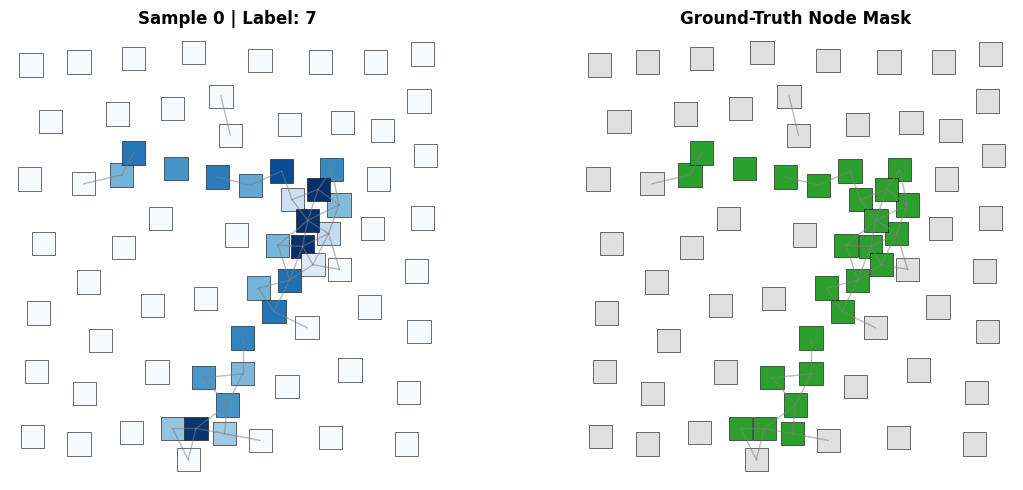

Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Label: 7 | Nodes: 75 | Edges: 83
GT mask positives: 25/75


In [8]:
# Visualization for explanation comparison: graph + label + GT node mask
import matplotlib.pyplot as plt
from pathlib import Path

candidate_roots = [
    project_root / 'data' / 'MNIST' / 'sparsified_pt_splits',
    project_root / 'shaique_updates' / 'codes' / 'MNISTsp' / 'data' / 'MNIST' / 'sparsified_pt_splits',
]

split_root = None
for root in candidate_roots:
    if (root / 'test_sparsified.pt').exists():
        split_root = root
        break

if split_root is None:
    raise FileNotFoundError('Could not find saved sparsified test split (.pt).')

test_dataset = torch.load(split_root / 'test_sparsified.pt', map_location='cpu', weights_only=False)

sample_idx = 0
graph_data = test_dataset[sample_idx]

if not hasattr(graph_data, 'node_mask') or graph_data.node_mask is None:
    raise ValueError('Ground-truth node mask not found in saved sample.')

x_coords = graph_data.pos[:, 0].cpu().numpy()
y_coords = graph_data.pos[:, 1].cpu().numpy()
row, col = graph_data.edge_index

intensity = graph_data.x[:, 0].cpu().numpy()
gt_mask = graph_data.node_mask.cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for i in range(graph_data.num_edges):
    s = graph_data.pos[row[i]].cpu().numpy()
    e = graph_data.pos[col[i]].cpu().numpy()
    ax1.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.3, linewidth=1)
    ax2.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.3, linewidth=1)

ax1.scatter(
    x_coords, y_coords, c=intensity, cmap='Blues',
    marker='s', s=280, edgecolor='black', linewidth=0.4
)
ax1.invert_yaxis()
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title(f'Sample {sample_idx} | Label: {int(graph_data.y.item())}', fontweight='bold')

cmap_binary = plt.cm.colors.ListedColormap(['#e0e0e0', '#2ca02c'])
ax2.scatter(
    x_coords, y_coords, c=gt_mask, cmap=cmap_binary,
    marker='s', s=280, edgecolor='black', linewidth=0.4, vmin=0, vmax=1
)
ax2.invert_yaxis()
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Ground-Truth Node Mask', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Using split directory: {split_root}')
print(f'Label: {int(graph_data.y.item())} | Nodes: {graph_data.num_nodes} | Edges: {graph_data.num_edges}')
print(f'GT mask positives: {int(graph_data.node_mask.sum().item())}/{graph_data.num_nodes}')

## BCos GIN + GT Mask Evaluation

In [7]:
from sklearn.metrics import roc_auc_score

class BcosGINConv(MessagePassing):
    def __init__(self, channels, b=2, max_out=1, eps=0.0, train_eps=False, **kwargs):
        kwargs.setdefault('aggr', 'add')
        super().__init__(**kwargs)
        self.transform = BcosSequential(
            *[
                BcosLinear(din, dout, b=b, max_out=max_out)
                for din, dout in zip(channels[:-1], channels[1:])
            ]
        )
        if train_eps:
            self.eps = torch.nn.Parameter(torch.tensor([eps], dtype=torch.float))
        else:
            self.register_buffer('eps', torch.tensor([eps], dtype=torch.float))

    def forward(self, x, edge_index):
        x_res = x
        out = self.propagate(edge_index, x=x)
        out = (1 + self.eps) * x_res + out
        return self.transform(out)

    def message(self, x_j):
        return x_j


class BCosGIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=4, b=2, max_out=1):
        super().__init__()
        self.lin_node = BcosLinear(in_channels, hidden_channels, b=b, max_out=max_out)
        self.convs = torch.nn.ModuleList(
            [BcosGINConv([hidden_channels, hidden_channels], b=b, max_out=max_out, train_eps=True) for _ in range(num_layers)]
        )
        self.agg = SumAggregation()
        self.readout = BcosSequential(
            BcosLinear(hidden_channels, hidden_channels, b=b, max_out=max_out),
            BcosLinear(hidden_channels, out_channels, b=b, max_out=max_out),
        )

    def forward(self, x, edge_index, batch):
        x = self.lin_node(x)
        for conv in self.convs:
            x = conv(x, edge_index)
        x = self.agg(x, batch)
        out = self.readout(x)
        return out


def train_bcos_gin(
    epochs=100,
    batch_size=64,
    lr=1e-3,
    hidden_channels=64,
    num_layers=4,
    use_scheduler=False,
    fixed_lr=5e-3,
    early_stopping=True,
    patience=15,
    min_delta=0.0,
 ):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    train_loader, val_loader, test_loader, dataset_info = load_and_split_data(batch_size=batch_size, add_pos_features=True)

    model = BCosGIN(
        in_channels=dataset_info['num_node_features'],
        hidden_channels=hidden_channels,
        out_channels=dataset_info['num_classes'],
        num_layers=num_layers,
        b=2,
        max_out=1,
    ).to(device)

    effective_lr = lr if use_scheduler else fixed_lr
    optimizer = torch.optim.Adam(model.parameters(), lr=effective_lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
        if use_scheduler
        else None
    )

    best_val_loss = float('inf')
    best_state = None
    wait = 0

    print('Starting BCos GIN training...')
    print(
        f'Config -> epochs={epochs}, batch_size={batch_size}, hidden={hidden_channels}, layers={num_layers}, '
        f'use_scheduler={use_scheduler}, lr={effective_lr}, early_stopping={early_stopping}, patience={patience}'
    )

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        improved = val_loss < (best_val_loss - min_delta)
        if improved:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        print(
            f'[BCOS] Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, '
            f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, LR: {current_lr:.6f}'
        )

        if early_stopping and wait >= patience:
            print(f'[BCOS] Early stopping at epoch {epoch} (no val loss improvement for {patience} epochs).')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion, device)
    print(f'[BCOS] Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}')

    return model, train_loader, val_loader, test_loader


def get_bcos_node_scores(model, data):
    model_device = next(model.parameters()).device
    data = data.to(model_device)
    batch = torch.zeros(data.x.size(0), dtype=torch.long, device=model_device)

    node_contrib = explain(model, data.x, data.edge_index, batch).detach()
    node_scores = node_contrib.abs().sum(dim=1).cpu().numpy()
    gt_mask = data.node_mask.detach().cpu().numpy().reshape(-1).astype(int)

    return node_scores, gt_mask


def evaluate_bcos_explanations(model, dataset, max_graphs=None):
    jaccards = []
    aurocs = []
    n = len(dataset) if max_graphs is None else min(len(dataset), max_graphs)

    for idx in range(n):
        data = dataset[idx].clone()
        if not hasattr(data, 'node_mask') or data.node_mask is None:
            continue

        scores, gt = get_bcos_node_scores(model, data)
        k = int(gt.sum())
        if k <= 0:
            continue

        top_k = np.argsort(scores)[-k:]
        pred = np.zeros_like(gt)
        pred[top_k] = 1

        intersection = np.logical_and(gt == 1, pred == 1).sum()
        union = np.logical_or(gt == 1, pred == 1).sum()
        jaccard = float(intersection / union) if union > 0 else 0.0
        jaccards.append(jaccard)

        if gt.min() != gt.max():
            aurocs.append(float(roc_auc_score(gt, scores)))

    mean_jacc = float(np.mean(jaccards)) if len(jaccards) else float('nan')
    mean_auroc = float(np.mean(aurocs)) if len(aurocs) else float('nan')

    print(f'[BCOS Explain] Graphs evaluated: {n}')
    print(f'[BCOS Explain] Mean Jaccard: {mean_jacc:.4f}')
    print(f'[BCOS Explain] Mean AUROC: {mean_auroc:.4f}')

    return {'jaccard': mean_jacc, 'auroc': mean_auroc, 'num_graphs': n}

In [8]:
# Run BCos-GIN with scheduler OFF and fixed LR, with early stopping
bcos_model, bcos_train_loader, bcos_val_loader, bcos_test_loader = train_bcos_gin(
    epochs=100,
    batch_size=64,
    lr=1e-3,
    hidden_channels=64,
    num_layers=4,
    use_scheduler=False,
    fixed_lr=5e-3,
    early_stopping=True,
    patience=15,
    min_delta=0.0,
 )

# Evaluate explanation quality on the entire test set
bcos_metrics = evaluate_bcos_explanations(
    bcos_model,
    bcos_test_loader.dataset,
    max_graphs=None,
 )

print('BCos explanation metrics:', bcos_metrics)

Using device: cpu
Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 4 (pos features added: True)
Starting BCos GIN training...
Config -> epochs=100, batch_size=64, hidden=64, layers=4, use_scheduler=False, lr=0.005, early_stopping=True, patience=15


[BCOS] Epoch 001, Train Loss: 2.0613, Val Loss: 1.9935, Val Acc: 0.2484, Val F1: 0.1488, LR: 0.005000


[BCOS] Epoch 002, Train Loss: 1.9964, Val Loss: 1.9361, Val Acc: 0.3162, Val F1: 0.2397, LR: 0.005000


[BCOS] Epoch 003, Train Loss: 1.9181, Val Loss: 1.8221, Val Acc: 0.3194, Val F1: 0.2629, LR: 0.005000


[BCOS] Epoch 004, Train Loss: 1.6440, Val Loss: 1.4845, Val Acc: 0.4844, Val F1: 0.4429, LR: 0.005000


...

[BCOS] Epoch 058, Train Loss: 0.1882, Val Loss: 0.2916, Val Acc: 0.9174, Val F1: 0.9169, LR: 0.005000


[BCOS] Epoch 059, Train Loss: 0.1954, Val Loss: 0.2757, Val Acc: 0.9194, Val F1: 0.9194, LR: 0.005000


[BCOS] Epoch 060, Train Loss: 0.1901, Val Loss: 0.2706, Val Acc: 0.9210, Val F1: 0.9213, LR: 0.005000


[BCOS] Epoch 061, Train Loss: 0.1785, Val Loss: 0.2701, Val Acc: 0.9162, Val F1: 0.9163, LR: 0.005000
[BCOS] Early stopping at epoch 61 (no val loss improvement for 15 epochs).


[BCOS] Test Loss: 0.2440, Test Acc: 0.9240, Test F1: 0.9237
[BCOS Explain] Graphs evaluated: 1000
[BCOS Explain] Mean Jaccard: 0.9336
[BCOS Explain] Mean AUROC: 0.9916
BCos explanation metrics: {'jaccard': 0.9336227932451514, 'auroc': 0.991556, 'num_graphs': 1000}


Checking MNIST Completeness: 100%|██████████| 500/500 [00:00<00:00, 886.41it/s]



B-cos MNIST Completeness Gap (MAE): 4.48e-07


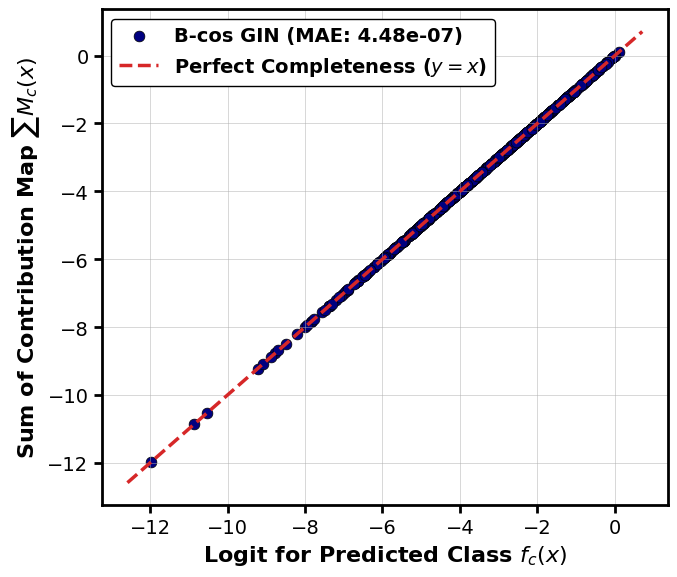

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm
from bcosgnn.explain import explain

# --- 1. Publication Quality Global Settings ---
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.labelweight': 'bold',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.figsize': (7, 6), 
    'axes.linewidth': 2.0,    
    'font.family': 'sans-serif' 
})

def run_mnist_completeness_check(dataset, model, device='cpu', max_samples=500):
    model.eval()
    
    bcos_logits = []
    bcos_contrib_sums = []

    # Iterate over the test set (limit to max_samples for speed)
    for i in tqdm(range(min(len(dataset), max_samples)), desc="Checking MNIST Completeness"):
        data = dataset[i].to(device)
        batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
        
        # 1. Get Model Prediction (Logits for all 10 digit classes)
        with torch.no_grad():
            logits = model(data.x, data.edge_index, batch)
            
            # Find the winning digit class
            pred_class = int(logits.argmax(dim=-1).item())
            
            # Get the exact logit score for that winning class
            target_logit = logits[0, pred_class].item()
            
        # 2. Get B-cos Contributions for the predicted class
        # Note: explain() automatically uses the max logit class
        contrib = explain(
            model,
            data.x,
            data.edge_index,
            batch
        )
        
        # 3. Sum the RAW (signed) node contributions
        # The 'explain' function here returns a tensor of node contributions
        total_contrib_sum = contrib.sum().item()
        
        # Store for plotting
        bcos_logits.append(target_logit)
        bcos_contrib_sums.append(total_contrib_sum)

    # --- Metrics ---
    bcos_mae = np.mean(np.abs(np.array(bcos_logits) - np.array(bcos_contrib_sums)))
    print(f"\nB-cos MNIST Completeness Gap (MAE): {bcos_mae:.2e}")

    # --- Plotting ---
    fig, ax = plt.subplots()

    # Plot B-cos data
    ax.scatter(bcos_logits, bcos_contrib_sums, alpha=1.0, s=60, 
               label=f'B-cos GIN (MAE: {bcos_mae:.2e})', color='navy', edgecolors='black', linewidths=0.5)

    # Plot the ideal "Perfect Completeness" line (y = x)
    min_val = min(min(bcos_logits), min(bcos_contrib_sums))
    max_val = max(max(bcos_logits), max(bcos_contrib_sums))
    
    buffer = (max_val - min_val) * 0.05
    if buffer == 0: buffer = 1.0 # Prevent zero buffer if all predictions are identical
        
    ax.plot([min_val - buffer, max_val + buffer], 
            [min_val - buffer, max_val + buffer], 
            color='#d62728', linestyle='--', linewidth=2.5, label='Perfect Completeness ($y=x$)')
    

    #ax.set_title('Completeness Check: B-cos GIN on MNISTsp', pad=15)
    ax.set_xlabel('Logit for Predicted Class $f_c(x)$')
    ax.set_ylabel('Sum of Contribution Map $\\sum M_c(x)$')

    # Configure Legend
    legend = ax.legend(loc='upper left', frameon=True, edgecolor='black', framealpha=1.0)
    for text in legend.get_texts():
        text.set_weight("bold")

    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
    ax.tick_params(axis='both', which='major', width=2.0, length=6)

    plt.tight_layout()
    plt.savefig('completeness_check_mnist_wo_title.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Run the check using the variables returned from your training cell
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
run_mnist_completeness_check(bcos_test_loader.dataset, bcos_model, device=device, max_samples=500)

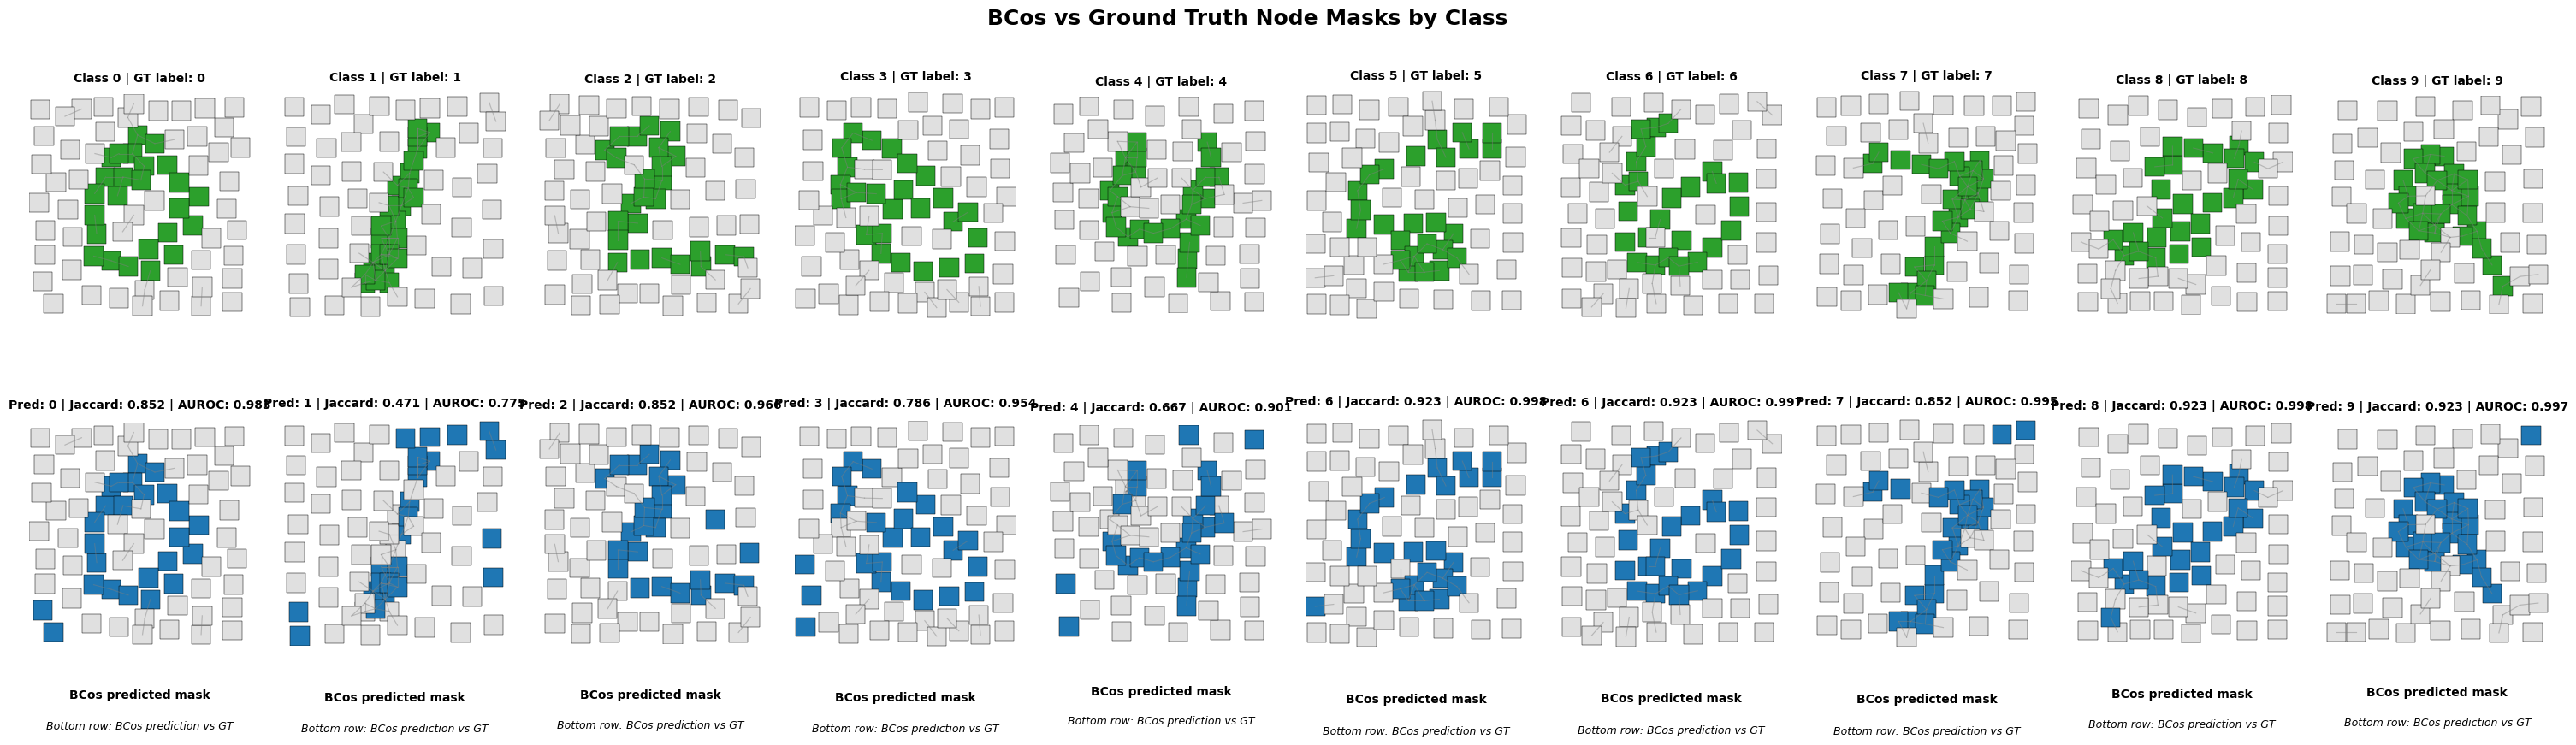

Class-wise BCos explanation visualization complete.
Top row = GT mask, bottom row = BCos predicted mask.


In [25]:
# Plot one sample per class: top row GT node mask, bottom row BCos predicted mask
import numpy as np
from sklearn.metrics import roc_auc_score

test_dataset = bcos_test_loader.dataset
samples_by_class = {}

for idx in range(len(test_dataset)):
    data = test_dataset[idx]
    label = int(data.y.item())
    if label not in samples_by_class:
        samples_by_class[label] = data.clone()
    if len(samples_by_class) == dataset_info['num_classes']:
        break

class_labels = sorted(samples_by_class.keys())
num_classes = len(class_labels)

fig, axes = plt.subplots(2, num_classes, figsize=(3.8 * num_classes, 8.8))
fig.subplots_adjust(top=0.88, bottom=0.12, wspace=0.15, hspace=0.35)
fig.suptitle('BCos vs Ground Truth Node Masks by Class', fontsize=18, fontweight='bold', y=0.98)

if num_classes == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for col_idx, class_label in enumerate(class_labels):
    graph_data = samples_by_class[class_label].clone()
    model_device = next(bcos_model.parameters()).device
    graph_data = graph_data.to(model_device)
    batch = torch.zeros(graph_data.x.size(0), dtype=torch.long, device=model_device)

    bcos_model.eval()
    with torch.no_grad():
        logits = bcos_model(graph_data.x, graph_data.edge_index, batch)
        pred_label = int(torch.argmax(logits, dim=-1).item())

    node_scores, gt_mask = get_bcos_node_scores(bcos_model, graph_data.clone())
    k = int(gt_mask.sum())
    pred_mask = np.zeros_like(gt_mask)
    if k > 0:
        top_k = np.argsort(node_scores)[-k:]
        pred_mask[top_k] = 1

    auc = float(roc_auc_score(gt_mask, node_scores)) if len(np.unique(gt_mask)) > 1 else float('nan')
    intersection = np.logical_and(pred_mask == 1, gt_mask == 1).sum()
    union = np.logical_or(pred_mask == 1, gt_mask == 1).sum()
    jaccard = float(intersection / union) if union > 0 else 0.0

    x_coords = graph_data.pos[:, 0].detach().cpu().numpy()
    y_coords = graph_data.pos[:, 1].detach().cpu().numpy()
    row, col = graph_data.edge_index

    ax_gt = axes[0, col_idx]
    ax_pred = axes[1, col_idx]

    for i in range(graph_data.num_edges):
        s = graph_data.pos[row[i]].detach().cpu().numpy()
        e = graph_data.pos[col[i]].detach().cpu().numpy()
        ax_gt.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.25, linewidth=0.8)
        ax_pred.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.25, linewidth=0.8)

    gt_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#2ca02c'])
    pred_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#1f77b4'])

    ax_gt.scatter(
        x_coords, y_coords, c=gt_mask, cmap=gt_cmap,
        marker='s', s=260, edgecolor='black', linewidth=0.35, vmin=0, vmax=1
    )
    ax_gt.invert_yaxis()
    ax_gt.set_aspect('equal')
    ax_gt.axis('off')
    ax_gt.set_title(f'Class {class_label} | GT label: {int(graph_data.y.item())}', fontsize=10, fontweight='bold', pad=10)

    ax_pred.scatter(
        x_coords, y_coords, c=pred_mask, cmap=pred_cmap,
        marker='s', s=260, edgecolor='black', linewidth=0.35, vmin=0, vmax=1
    )
    ax_pred.invert_yaxis()
    ax_pred.set_aspect('equal')
    ax_pred.axis('off')
    ax_pred.set_title(f'Pred: {pred_label} | Jaccard: {jaccard:.3f} | AUROC: {auc:.3f}', fontsize=10, fontweight='bold', pad=12)
    ax_pred.text(
        0.5, -0.20,
        'BCos predicted mask',
        transform=ax_pred.transAxes,
        ha='center',
        va='top',
        fontsize=10,
        fontweight='bold'
    )

for ax in axes[1, :]:
    ax.text(
        0.5, -0.34,
        'Bottom row: BCos prediction vs GT',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=9,
        fontstyle='italic'
    )

plt.show()

print('Class-wise BCos explanation visualization complete.')
print('Top row = GT mask, bottom row = BCos predicted mask.')

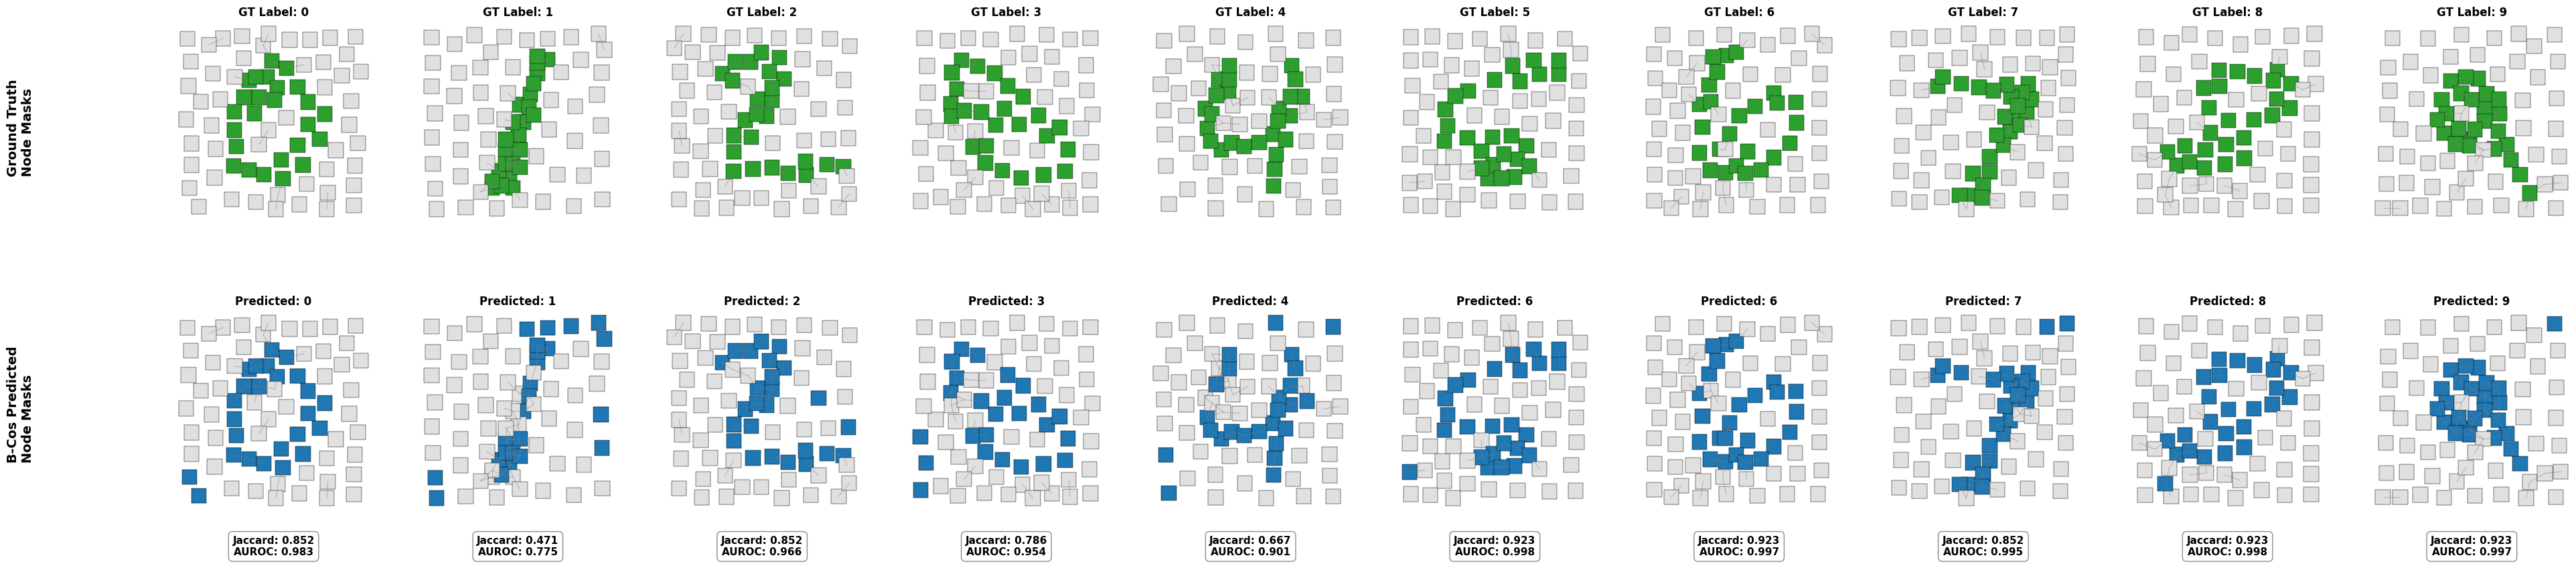

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Ensure your model is in eval mode
bcos_model.eval()
model_device = next(bcos_model.parameters()).device

# Get the test dataset from your loader
test_dataset = bcos_test_loader.dataset
samples_by_class = {}

# Collect one sample per class (0-9)
for idx in range(len(test_dataset)):
    data = test_dataset[idx]
    label = int(data.y.item())
    if label not in samples_by_class:
        samples_by_class[label] = data.clone()
    if len(samples_by_class) == dataset_info['num_classes']:
        break

class_labels = sorted(samples_by_class.keys())
num_classes = len(class_labels)

# ---------------------------------------------------------
# Setup Figure with Fixed Spacing
# ---------------------------------------------------------
fig, axes = plt.subplots(2, num_classes, figsize=(4 * num_classes, 9))

# hspace=0.5 gives vertical breathing room between rows
# left=0.08 gives room for the row titles on the far left
fig.subplots_adjust(top=0.90, bottom=0.10, left=0.08, right=0.98, wspace=0.15, hspace=0.5)

# Add Row Identifiers rotated on the far left side
fig.text(0.02, 0.73, 'Ground Truth\nNode Masks', fontsize=14, fontweight='bold', va='center', rotation=90)
fig.text(0.02, 0.27, 'B-Cos Predicted\nNode Masks', fontsize=14, fontweight='bold', va='center', rotation=90)

if num_classes == 1:
    axes = np.array([[axes[0]], [axes[1]]])

# ---------------------------------------------------------
# Plotting Loop
# ---------------------------------------------------------
for col_idx, class_label in enumerate(class_labels):
    graph_data = samples_by_class[class_label].clone().to(model_device)
    batch = torch.zeros(graph_data.x.size(0), dtype=torch.long, device=model_device)

    # 1. Get Model Prediction
    with torch.no_grad():
        logits = bcos_model(graph_data.x, graph_data.edge_index, batch)
        pred_label = int(torch.argmax(logits, dim=-1).item())

    # 2. Get B-Cos Explanation Scores (Assuming get_bcos_node_scores is defined)
    node_scores, gt_mask = get_bcos_node_scores(bcos_model, graph_data.clone())
    
    # 3. Calculate Top-K Mask and Metrics
    k = int(gt_mask.sum())
    pred_mask = np.zeros_like(gt_mask)
    if k > 0:
        top_k = np.argsort(node_scores)[-k:]
        pred_mask[top_k] = 1

    auc = float(roc_auc_score(gt_mask, node_scores)) if len(np.unique(gt_mask)) > 1 else float('nan')
    intersection = np.logical_and(pred_mask == 1, gt_mask == 1).sum()
    union = np.logical_or(pred_mask == 1, gt_mask == 1).sum()
    jaccard = float(intersection / union) if union > 0 else 0.0

    # Data for plotting
    x_coords = graph_data.pos[:, 0].detach().cpu().numpy()
    y_coords = graph_data.pos[:, 1].detach().cpu().numpy()
    row, col = graph_data.edge_index
    
    ax_gt = axes[0, col_idx]
    ax_pred = axes[1, col_idx]

    # --- TOP ROW: Ground Truth Plot ---
    # Draw edges
    for i in range(graph_data.num_edges):
        s = graph_data.pos[row[i]].detach().cpu().numpy()
        e = graph_data.pos[col[i]].detach().cpu().numpy()
        ax_gt.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.25, linewidth=0.8)
    
    # Draw GT nodes
    gt_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#2ca02c']) # Gray / Green
    ax_gt.scatter(x_coords, y_coords, c=gt_mask, cmap=gt_cmap,
                  marker='s', s=260, edgecolor='black', linewidth=0.35, vmin=0, vmax=1)
    ax_gt.invert_yaxis()
    ax_gt.set_aspect('equal')
    ax_gt.axis('off')
    # Title placed strictly at the top of the GT image
    ax_gt.set_title(f'GT Label: {int(graph_data.y.item())}', fontsize=12, fontweight='bold', pad=10)

    # --- BOTTOM ROW: B-Cos Prediction Plot ---
    # Draw edges
    for i in range(graph_data.num_edges):
        s = graph_data.pos[row[i]].detach().cpu().numpy()
        e = graph_data.pos[col[i]].detach().cpu().numpy()
        ax_pred.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.25, linewidth=0.8)
    
    # Draw Predicted nodes
    pred_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#1f77b4']) # Gray / Blue
    ax_pred.scatter(x_coords, y_coords, c=pred_mask, cmap=pred_cmap,
                    marker='s', s=260, edgecolor='black', linewidth=0.35, vmin=0, vmax=1)
    ax_pred.invert_yaxis()
    ax_pred.set_aspect('equal')
    ax_pred.axis('off')
    # Title placed strictly at the top of the Pred image
    ax_pred.set_title(f'Predicted: {pred_label}', fontsize=12, fontweight='bold', pad=10)
    
    # Metrics placed neatly below the Pred image inside a white box
    ax_pred.text(0.5, -0.15, f'Jaccard: {jaccard:.3f}\nAUROC: {auc:.3f}', 
                 transform=ax_pred.transAxes, ha='center', va='top', 
                 fontsize=11, fontweight='semibold',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.4'))

plt.show()

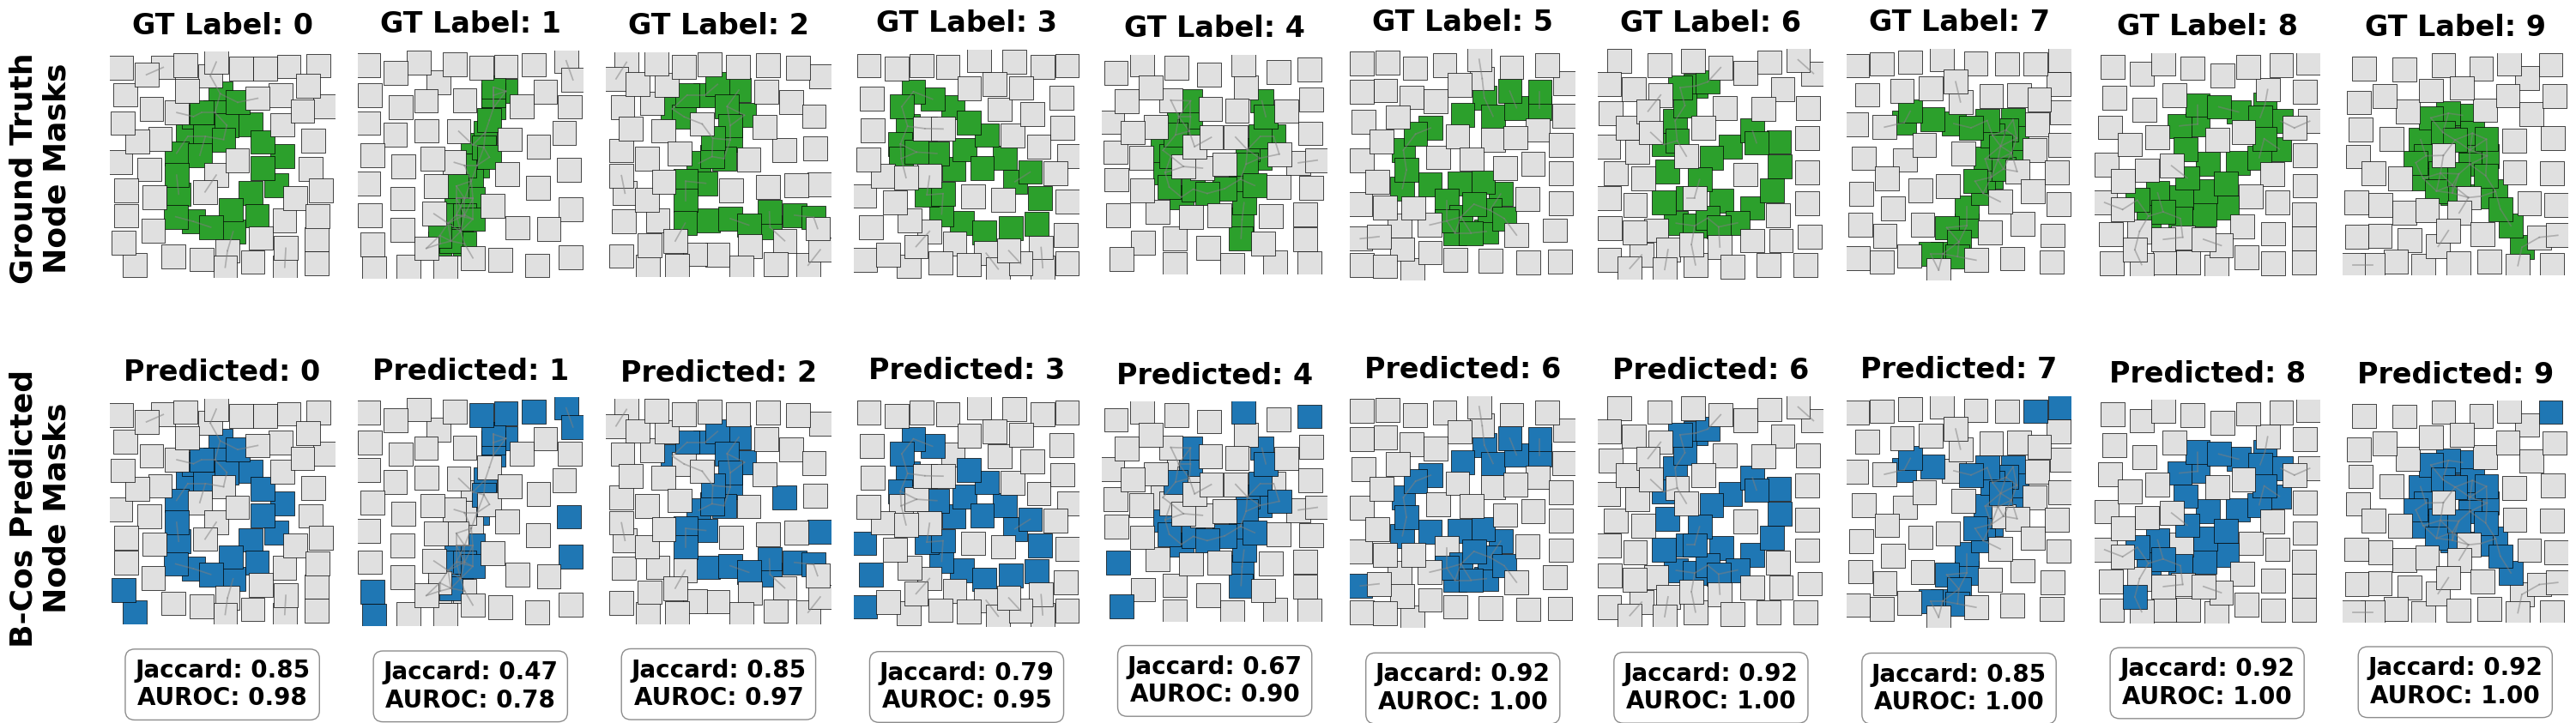

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Ensure your model is in eval mode
bcos_model.eval()
model_device = next(bcos_model.parameters()).device

# Get the test dataset from your loader
test_dataset = bcos_test_loader.dataset
samples_by_class = {}

# Collect one sample per class
for idx in range(len(test_dataset)):
    data = test_dataset[idx]
    label = int(data.y.item())
    if label not in samples_by_class:
        samples_by_class[label] = data.clone()
    if len(samples_by_class) == dataset_info['num_classes']:
        break

class_labels = sorted(samples_by_class.keys())
num_classes = len(class_labels)

# ---------------------------------------------------------
# Setup Publication-Ready Figure
# ---------------------------------------------------------
# Slightly more compact width so it scales down better in LaTeX
fig, axes = plt.subplots(2, num_classes, figsize=(3 * num_classes, 9))

# Drastically reduced 'left' margin to reclaim wasted space
fig.subplots_adjust(top=0.88, bottom=0.12, left=0.035, right=0.99, wspace=0.1, hspace=0.45)

# Row Identifiers with HUGE fonts for scaling
fig.text(0.008, 0.72, 'Ground Truth\nNode Masks', fontsize=26, fontweight='bold', va='center', ha='center', rotation=90)
fig.text(0.008, 0.28, 'B-Cos Predicted\nNode Masks', fontsize=26, fontweight='bold', va='center', ha='center', rotation=90)

if num_classes == 1:
    axes = np.array([[axes[0]], [axes[1]]])

# ---------------------------------------------------------
# Plotting Loop
# ---------------------------------------------------------
for col_idx, class_label in enumerate(class_labels):
    graph_data = samples_by_class[class_label].clone().to(model_device)
    batch = torch.zeros(graph_data.x.size(0), dtype=torch.long, device=model_device)

    # 1. Get Model Prediction
    with torch.no_grad():
        logits = bcos_model(graph_data.x, graph_data.edge_index, batch)
        pred_label = int(torch.argmax(logits, dim=-1).item())

    # 2. Get B-Cos Explanation Scores
    node_scores, gt_mask = get_bcos_node_scores(bcos_model, graph_data.clone())
    
    # 3. Calculate Top-K Mask and Metrics
    k = int(gt_mask.sum())
    pred_mask = np.zeros_like(gt_mask)
    if k > 0:
        top_k = np.argsort(node_scores)[-k:]
        pred_mask[top_k] = 1

    auc = float(roc_auc_score(gt_mask, node_scores)) if len(np.unique(gt_mask)) > 1 else float('nan')
    intersection = np.logical_and(pred_mask == 1, gt_mask == 1).sum()
    union = np.logical_or(pred_mask == 1, gt_mask == 1).sum()
    jaccard = float(intersection / union) if union > 0 else 0.0

    # Data for plotting
    x_coords = graph_data.pos[:, 0].detach().cpu().numpy()
    y_coords = graph_data.pos[:, 1].detach().cpu().numpy()
    row, col = graph_data.edge_index
    
    ax_gt = axes[0, col_idx]
    ax_pred = axes[1, col_idx]

    # --- TOP ROW: Ground Truth Plot ---
    # Draw edges slightly thicker for print visibility
    for i in range(graph_data.num_edges):
        s = graph_data.pos[row[i]].detach().cpu().numpy()
        e = graph_data.pos[col[i]].detach().cpu().numpy()
        ax_gt.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.3, linewidth=1.2)
    
    # Draw GT nodes (Increased size to 400)
    gt_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#2ca02c'])
    ax_gt.scatter(x_coords, y_coords, c=gt_mask, cmap=gt_cmap,
                  marker='s', s=400, edgecolor='black', linewidth=0.5, vmin=0, vmax=1)
    ax_gt.invert_yaxis()
    ax_gt.set_aspect('equal')
    ax_gt.axis('off')
    
    # Massive title font
    ax_gt.set_title(f'GT Label: {int(graph_data.y.item())}', fontsize=24, fontweight='bold', pad=15)

    # --- BOTTOM ROW: B-Cos Prediction Plot ---
    for i in range(graph_data.num_edges):
        s = graph_data.pos[row[i]].detach().cpu().numpy()
        e = graph_data.pos[col[i]].detach().cpu().numpy()
        ax_pred.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.3, linewidth=1.2)
    
    # Draw Predicted nodes
    pred_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#1f77b4'])
    ax_pred.scatter(x_coords, y_coords, c=pred_mask, cmap=pred_cmap,
                    marker='s', s=400, edgecolor='black', linewidth=0.5, vmin=0, vmax=1)
    ax_pred.invert_yaxis()
    ax_pred.set_aspect('equal')
    ax_pred.axis('off')
    
    # Massive title font
    ax_pred.set_title(f'Predicted: {pred_label}', fontsize=24, fontweight='bold', pad=15)
    
    # Large metrics text
    ax_pred.text(0.5, -0.15, f'Jaccard: {jaccard:.2f}\nAUROC: {auc:.2f}', 
                 transform=ax_pred.transAxes, ha='center', va='top', 
                 fontsize=20, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.4'))

plt.show()

Publication-ready figure saved successfully as: BCos_MNIST75sp_Explanations.pdf


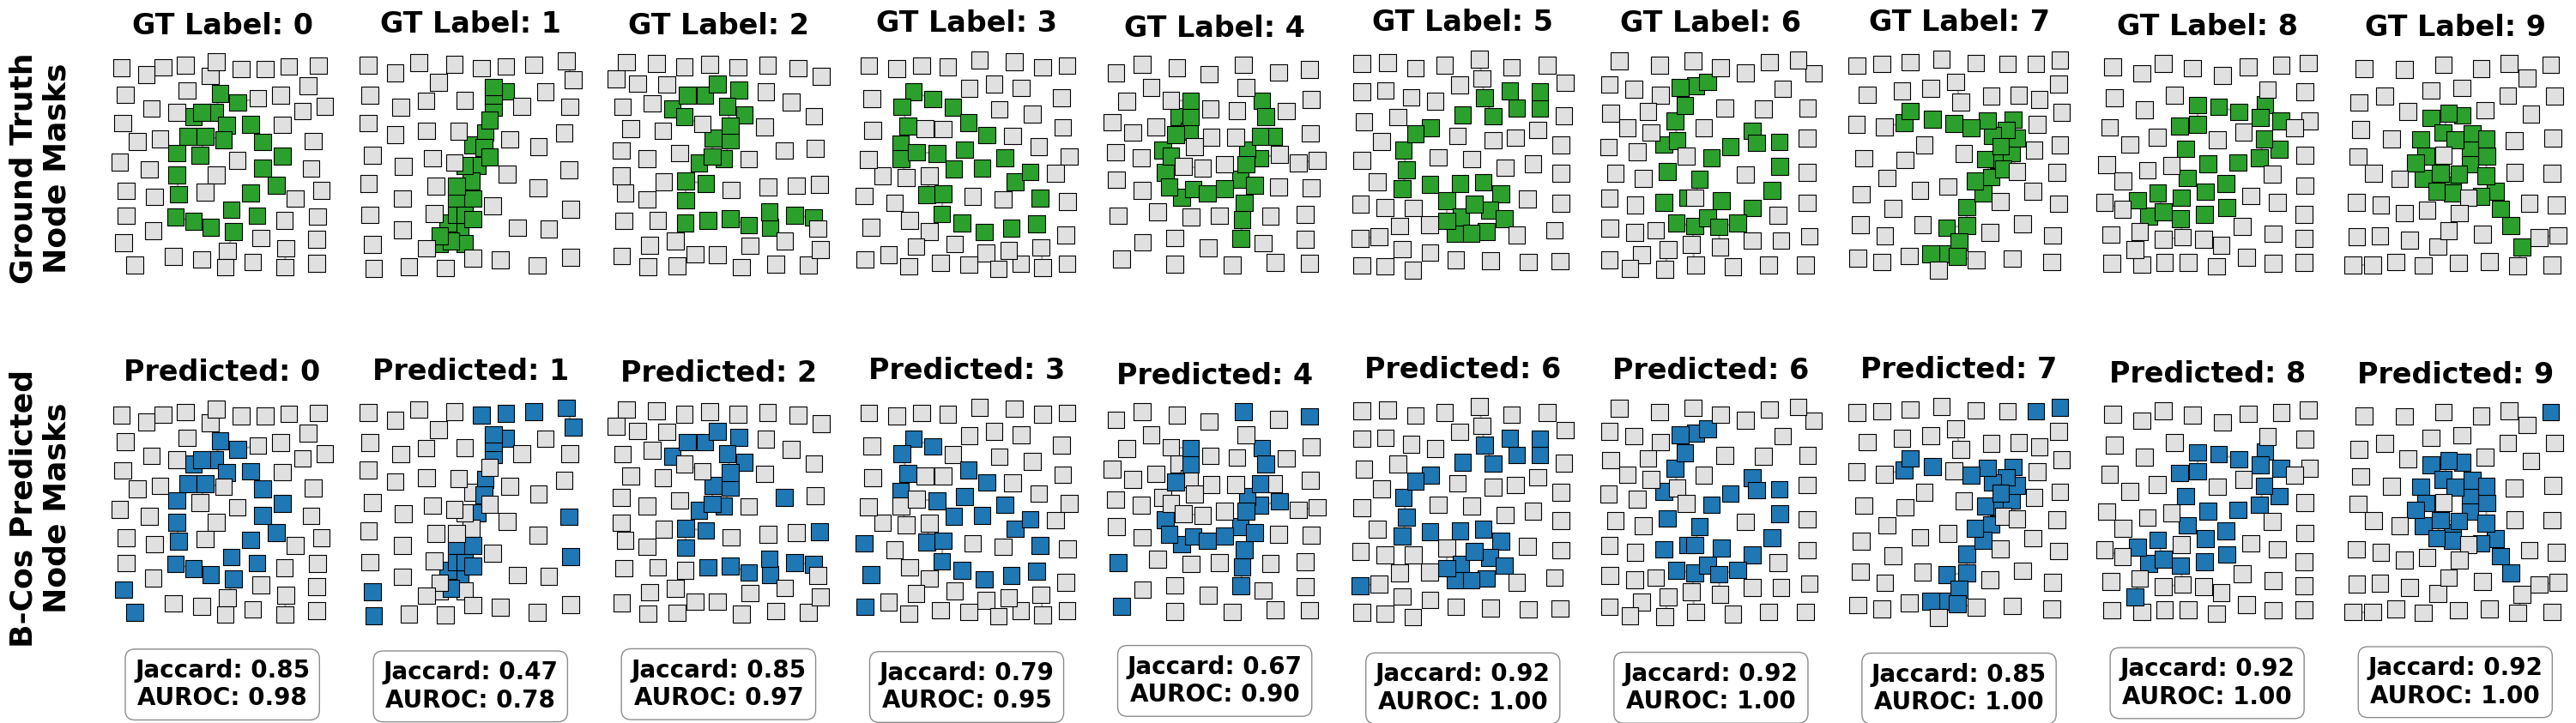

In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Ensure your model is in eval mode
bcos_model.eval()
model_device = next(bcos_model.parameters()).device

# Get the test dataset from your loader
test_dataset = bcos_test_loader.dataset
samples_by_class = {}

# Collect one sample per class
for idx in range(len(test_dataset)):
    data = test_dataset[idx]
    label = int(data.y.item())
    if label not in samples_by_class:
        samples_by_class[label] = data.clone()
    if len(samples_by_class) == dataset_info['num_classes']:
        break

class_labels = sorted(samples_by_class.keys())
num_classes = len(class_labels)

# ---------------------------------------------------------
# Setup Publication-Ready Figure
# ---------------------------------------------------------
fig, axes = plt.subplots(2, num_classes, figsize=(3 * num_classes, 9))

# Tight margins to maximize real estate
fig.subplots_adjust(top=0.88, bottom=0.12, left=0.035, right=0.99, wspace=0.1, hspace=0.45)

# Row Identifiers with HUGE fonts for scaling down in PDFs
fig.text(0.008, 0.72, 'Ground Truth\nNode Masks', fontsize=26, fontweight='bold', va='center', ha='center', rotation=90)
fig.text(0.008, 0.28, 'B-Cos Predicted\nNode Masks', fontsize=26, fontweight='bold', va='center', ha='center', rotation=90)

if num_classes == 1:
    axes = np.array([[axes[0]], [axes[1]]])

# ---------------------------------------------------------
# Plotting Loop
# ---------------------------------------------------------
for col_idx, class_label in enumerate(class_labels):
    graph_data = samples_by_class[class_label].clone().to(model_device)
    batch = torch.zeros(graph_data.x.size(0), dtype=torch.long, device=model_device)

    # 1. Get Model Prediction
    with torch.no_grad():
        logits = bcos_model(graph_data.x, graph_data.edge_index, batch)
        pred_label = int(torch.argmax(logits, dim=-1).item())

    # 2. Get B-Cos Explanation Scores
    node_scores, gt_mask = get_bcos_node_scores(bcos_model, graph_data.clone())
    
    # 3. Calculate Top-K Mask and Metrics
    k = int(gt_mask.sum())
    pred_mask = np.zeros_like(gt_mask)
    if k > 0:
        top_k = np.argsort(node_scores)[-k:]
        pred_mask[top_k] = 1

    auc = float(roc_auc_score(gt_mask, node_scores)) if len(np.unique(gt_mask)) > 1 else float('nan')
    intersection = np.logical_and(pred_mask == 1, gt_mask == 1).sum()
    union = np.logical_or(pred_mask == 1, gt_mask == 1).sum()
    jaccard = float(intersection / union) if union > 0 else 0.0

    # Data for plotting
    x_coords = graph_data.pos[:, 0].detach().cpu().numpy()
    y_coords = graph_data.pos[:, 1].detach().cpu().numpy()
    row, col = graph_data.edge_index
    
    ax_gt = axes[0, col_idx]
    ax_pred = axes[1, col_idx]

    # --- TOP ROW: Ground Truth Plot ---
    for i in range(graph_data.num_edges):
        s = graph_data.pos[row[i]].detach().cpu().numpy()
        e = graph_data.pos[col[i]].detach().cpu().numpy()
        ax_gt.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.4, linewidth=1.5)
    
    # Draw spaced-out SQUARE nodes
    gt_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#2ca02c'])
    ax_gt.scatter(x_coords, y_coords, c=gt_mask, cmap=gt_cmap,
                  marker='s', s=200, edgecolor='black', linewidth=0.8, vmin=0, vmax=1, zorder=5)
    
    ax_gt.invert_yaxis()
    ax_gt.set_aspect('equal')
    ax_gt.axis('off')
    ax_gt.set_title(f'GT Label: {int(graph_data.y.item())}', fontsize=24, fontweight='bold', pad=15)

    # --- BOTTOM ROW: B-Cos Prediction Plot ---
    for i in range(graph_data.num_edges):
        s = graph_data.pos[row[i]].detach().cpu().numpy()
        e = graph_data.pos[col[i]].detach().cpu().numpy()
        ax_pred.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.4, linewidth=1.5)
    
    # Draw spaced-out SQUARE nodes
    pred_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#1f77b4'])
    ax_pred.scatter(x_coords, y_coords, c=pred_mask, cmap=pred_cmap,
                    marker='s', s=200, edgecolor='black', linewidth=0.8, vmin=0, vmax=1, zorder=5)
    
    ax_pred.invert_yaxis()
    ax_pred.set_aspect('equal')
    ax_pred.axis('off')
    ax_pred.set_title(f'Predicted: {pred_label}', fontsize=24, fontweight='bold', pad=15)
    
    # Large metrics text
    ax_pred.text(0.5, -0.15, f'Jaccard: {jaccard:.2f}\nAUROC: {auc:.2f}', 
                 transform=ax_pred.transAxes, ha='center', va='top', 
                 fontsize=20, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.4'))

# ---------------------------------------------------------
# Save to PDF
# ---------------------------------------------------------
output_filename = 'BCos_MNIST75sp_Explanations.pdf'

# bbox_inches='tight' ensures the rotated text on the left doesn't get clipped
plt.savefig(output_filename, format='pdf', bbox_inches='tight', dpi=300)
print(f"Publication-ready figure saved successfully as: {output_filename}")

plt.show()

In [10]:
def visualize_feature_contributions(model, dataset, target_classes=[1, 4], num_samples=2):
    """
    Visualizes the B-cos contribution maps broken down by individual features
    (Intensity, Pos X, Pos Y) to diagnose spatial biases.
    """
    import matplotlib.pyplot as plt
    
    model.eval()
    device = next(model.parameters()).device
    
    # Features based on _augment_with_normalized_pos: [intensity, 1-intensity, pos_x, pos_y]
    feature_names = ["Overall (Summed)", "Feature 0: Intensity", "Feature 2: X-Position", "Feature 3: Y-Position"]
    num_cols = 1 + len(feature_names) # Original + 4 explanation columns
    
    total_rows = len(target_classes) * num_samples
    fig, axes = plt.subplots(total_rows, num_cols, figsize=(4 * num_cols, 4 * total_rows))
    
    row_idx = 0
    
    for target_class in target_classes:
        samples_found = 0
        
        for data in dataset:
            if samples_found >= num_samples:
                break
                
            data = data.to(device)
            batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
            
            with torch.no_grad():
                logits = model(data.x, data.edge_index, batch)
                pred_class = logits.argmax(dim=1).item()
            
            if pred_class == target_class:
                # Get raw explanations: shape [num_nodes, num_features]
                node_contrib = explain(model, data.x, data.edge_index, batch).detach()
                
                # Extract features for plotting
                pos = data.pos.cpu().numpy()
                intensity = data.x[:, 0].cpu().numpy()
                
                # Calculate absolute contributions
                overall_score = node_contrib.abs().sum(dim=1).cpu().numpy()
                intensity_score = node_contrib[:, 0].abs().cpu().numpy()
                pos_x_score = node_contrib[:, 2].abs().cpu().numpy()
                pos_y_score = node_contrib[:, 3].abs().cpu().numpy()
                
                scores_to_plot = [overall_score, intensity_score, pos_x_score, pos_y_score]
                
                # Plot 1: Original Image
                ax = axes[row_idx, 0]
                ax.scatter(pos[:, 0], pos[:, 1], c=intensity, cmap='Greys', s=60)
                ax.set_title(f"True: {data.y.item()} | Pred: {pred_class}\nOriginal Intensity")
                ax.invert_yaxis()
                ax.axis('equal')
                ax.axis('off')
                
                # Plot the Contribution Maps
                for col_idx, (score, name) in enumerate(zip(scores_to_plot, feature_names)):
                    ax = axes[row_idx, col_idx + 1]
                    sc = ax.scatter(pos[:, 0], pos[:, 1], c=score, cmap='magma', s=60)
                    ax.set_title(name)
                    ax.invert_yaxis()
                    ax.axis('equal')
                    ax.axis('off')
                    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
                
                row_idx += 1
                samples_found += 1

    plt.tight_layout()
    plt.show()


=== Generating Feature Contribution Maps ===
Using device: cpu
Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 4 (pos features added: True)
Starting BCos GIN training...
Config -> epochs=100, batch_size=64, hidden=64, layers=4, use_scheduler=False, lr=0.005, early_stopping=True, patience=15


[BCOS] Epoch 001, Train Loss: 2.0740, Val Loss: 2.0071, Val Acc: 0.2558, Val F1: 0.1729, LR: 0.005000


[BCOS] Epoch 002, Train Loss: 1.9890, Val Loss: 1.8783, Val Acc: 0.3220, Val F1: 0.2679, LR: 0.005000


[BCOS] Epoch 003, Train Loss: 1.8874, Val Loss: 1.7563, Val Acc: 0.3656, Val F1: 0.3410, LR: 0.005000


[BCOS] Epoch 004, Train Loss: 1.6367, Val Loss: 1.5330, Val Acc: 0.4640, Val F1: 0.4306, LR: 0.005000


...

[BCOS] Epoch 069, Train Loss: 0.1648, Val Loss: 0.2587, Val Acc: 0.9288, Val F1: 0.9285, LR: 0.005000


[BCOS] Epoch 070, Train Loss: 0.1721, Val Loss: 0.2847, Val Acc: 0.9150, Val F1: 0.9154, LR: 0.005000


[BCOS] Epoch 071, Train Loss: 0.1646, Val Loss: 0.2633, Val Acc: 0.9254, Val F1: 0.9257, LR: 0.005000


[BCOS] Epoch 072, Train Loss: 0.1624, Val Loss: 0.2790, Val Acc: 0.9198, Val F1: 0.9200, LR: 0.005000
[BCOS] Early stopping at epoch 72 (no val loss improvement for 15 epochs).


[BCOS] Test Loss: 0.2123, Test Acc: 0.9370, Test F1: 0.9371


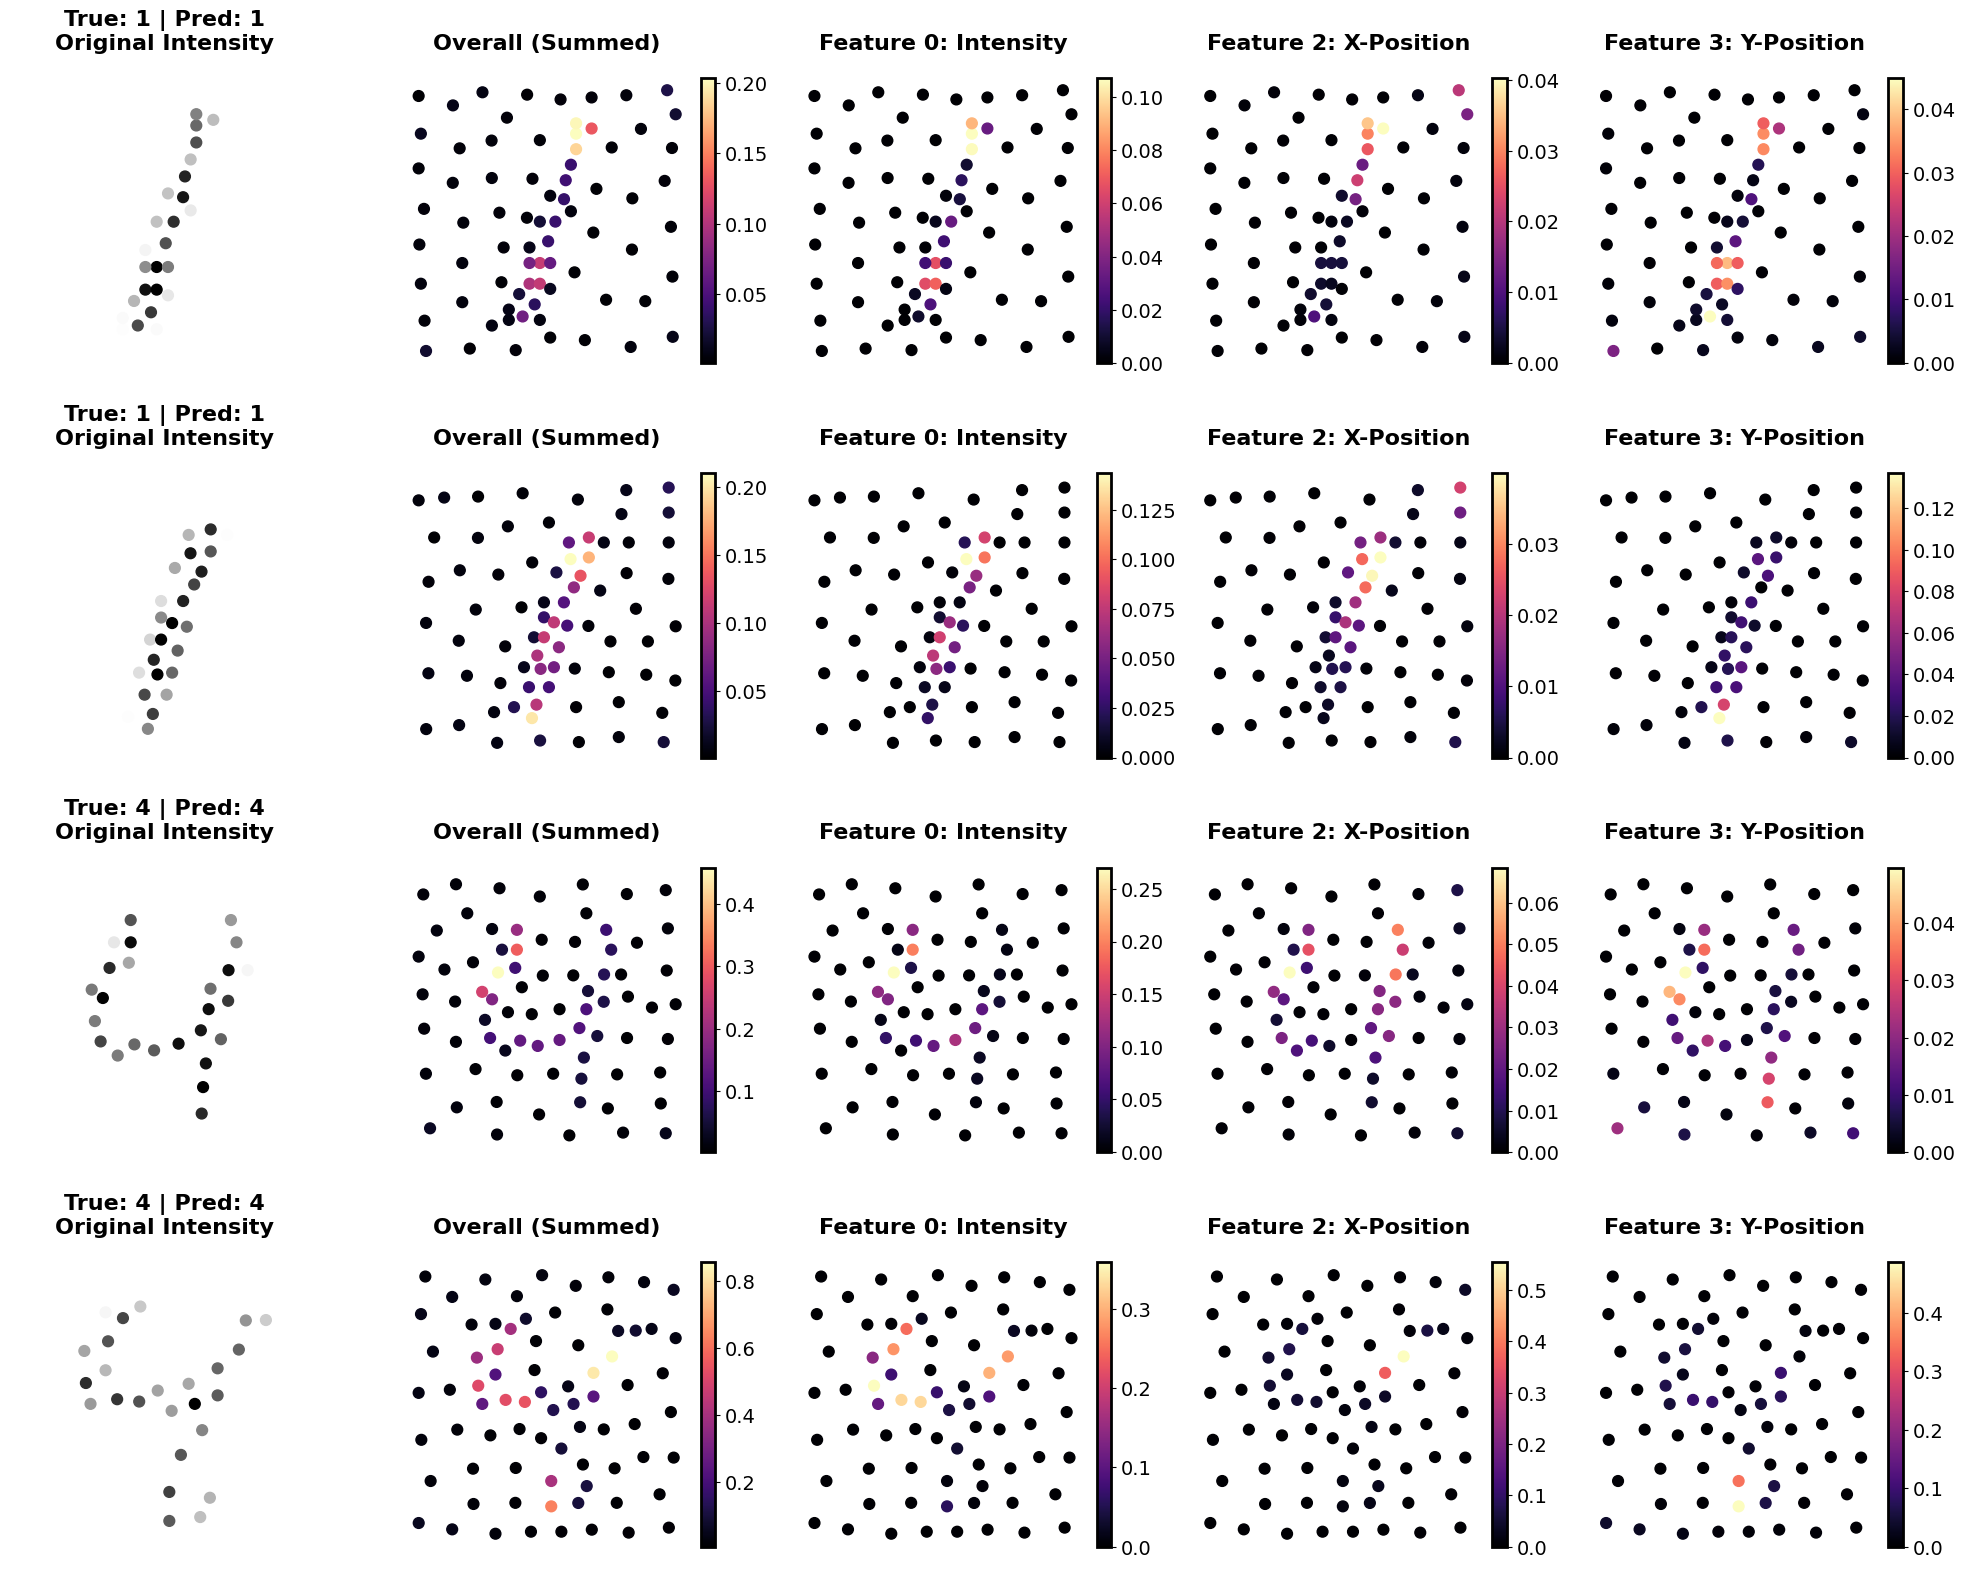

In [19]:
# ==========================================
# Visualization Generation
# ==========================================
print("\n=== Generating Feature Contribution Maps ===")

# 1. Train a single model for visualization (you can lower epochs if you just want to test it quickly)
model, train_loader, val_loader, test_loader = train_bcos_gin(epochs=100)

# 2. Run the visualization for labels 1 and 4
visualize_feature_contributions(model, test_loader.dataset, target_classes=[1, 4], num_samples=2)